In [1]:
from dataclasses import asdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_1 = pd.read_csv("violent_events_1.csv", sep=";", skipinitialspace=True)

In [3]:
df_2 = pd.read_csv("violent_events_2.csv", sep=";", skipinitialspace=True)

In [4]:
df_3 = pd.read_csv("violent_events_3.csv", sep=";", skipinitialspace=True)

In [5]:
df_ipc = pd.read_csv("ipc_global_area_long_pcoded.csv", skipinitialspace=True)

In [6]:
df_violence = pd.concat([df_1, df_2, df_3])

In [7]:
df_violence.head()

,Country,Admin1,Admin2,ISO3,Admin2 Pcode,Admin1 Pcode,Month,Year,Events,Fatalities
0,Haiti,Ouest,Archaie,HTI,HT0142,HT01,January,2018,0,0
1,Haiti,Nord-Ouest,Mole Saint Nicolas,HTI,HT0931,HT09,January,2018,0,0
2,Haiti,Centre,Hinche,HTI,HT0611,HT06,January,2018,0,0
3,Haiti,Nord,Acul Du Nord,HTI,HT0321,HT03,January,2018,0,0
4,Haiti,Ouest,Port-au-Prince,HTI,HT0111,HT01,January,2018,1,0


In [8]:
#Creazione di una lista che contiene tutti i paesi presenti nel dataset ipc
lista_paesi_ipc = df_ipc.Country.unique().tolist()

# 1. Definizione del dizionario (Codici ISO Alpha-3)
country_mapping = {
    'Haiti': 'HTI', 'Lebanon': 'LBN', 'Mali': 'MLI', 'Mozambique': 'MOZ',
    'Myanmar': 'MMR', 'Niger': 'NER', 'Nigeria': 'NGA', 'Palestine': 'PSE',
    'Somalia': 'SOM', 'South Sudan': 'SSD', 'Sudan': 'SDN', 'Syria': 'SYR',
    'Venezuela': 'VEN', 'Yemen': 'YEM', 'Afghanistan': 'AFG', 'Burkina Faso': 'BFA',
    'Burundi': 'BDI', 'Cameroon': 'CMR', 'Central African Republic': 'CAF',
    'Chad': 'TCD', 'Colombia': 'COL', 'Democratic Republic of Congo': 'COD',
    'Ethiopia': 'ETH', 'Ukraine': 'UKR', 'Albania': 'ALB', 'Algeria': 'DZA',
    'American Samoa': 'ASM', 'Andorra': 'AND', 'Angola': 'AGO', 'Anguilla': 'AIA',
    'Antarctica': 'ATA', 'Antigua and Barbuda': 'ATG', 'Argentina': 'ARG',
    'Armenia': 'ARM', 'Aruba': 'ABW', 'Australia': 'AUS', 'Austria': 'AUT',
    'Azerbaijan': 'AZE', 'Bahamas': 'BHS', 'Bahrain': 'BHR', 'Bailiwick of Guernsey': 'GGY',
    'Bailiwick of Jersey': 'JEY', 'Bangladesh': 'BGD', 'Barbados': 'BRB',
    'Belarus': 'BLR', 'Belgium': 'BEL', 'Belize': 'BLZ', 'Benin': 'BEN',
    'Bermuda': 'BMU', 'Bhutan': 'BTN', 'Bolivia': 'BOL', 'Bosnia and Herzegovina': 'BIH',
    'Botswana': 'BWA', 'Brazil': 'BRA', 'British Indian Ocean Territory': 'IOT',
    'British Virgin Islands': 'VGB', 'Brunei': 'BRN', 'Bulgaria': 'BGR',
    'Cambodia': 'KHM', 'Canada': 'CAN', 'Cape Verde': 'CPV', 'Caribbean Netherlands': 'BES',
    'Cayman Islands': 'CYM', 'Chile': 'CHL', 'China': 'CHN', 'Christmas Island': 'CXR',
    'Cocos (Keeling) Islands': 'CCK', 'Comoros': 'COM', 'Cook Islands': 'COK',
    'Costa Rica': 'CRI', 'Croatia': 'HRV', 'Cuba': 'CUB', 'Curacao': 'CUW',
    'Cyprus': 'CYP', 'Czech Republic': 'CZE', 'Denmark': 'DNK', 'Djibouti': 'DJI',
    'Dominica': 'DMA', 'Dominican Republic': 'DOM', 'East Timor': 'TLS',
    'Ecuador': 'ECU', 'Egypt': 'EGY', 'El Salvador': 'SLV', 'Equatorial Guinea': 'GNQ',
    'Eritrea': 'ERI', 'Estonia': 'EST', 'eSwatini': 'SWZ', 'Falkland Islands': 'FLK',
    'Faroe Islands': 'FRO', 'Fiji': 'FJI', 'Finland': 'FIN', 'France': 'FRA',
    'French Guiana': 'GUF', 'French Polynesia': 'PYF', 'Gabon': 'GAB', 'Gambia': 'GMB',
    'Georgia': 'GEO', 'Germany': 'DEU', 'Ghana': 'GHA', 'Gibraltar': 'GIB',
    'Greece': 'GRC', 'Greenland': 'GRL', 'Grenada': 'GRD', 'Guadeloupe': 'GLP',
    'Guam': 'GUM', 'Guatemala': 'GTM', 'Guinea': 'GIN', 'Guinea-Bissau': 'GNB',
    'Guyana': 'GUY', 'Heard Island and McDonald Islands': 'HMD', 'Honduras': 'HND',
    'Hungary': 'HUN', 'Iceland': 'ISL', 'India': 'IND', 'Indonesia': 'IDN',
    'Iran': 'IRN', 'Iraq': 'IRQ', 'Ireland': 'IRL', 'Isle of Man': 'IMN',
    'Israel': 'ISR', 'Italy': 'ITA', 'Ivory Coast': 'CIV', 'Jamaica': 'JAM',
    'Japan': 'JPN', 'Jordan': 'JOR', 'Kazakhstan': 'KAZ', 'Kenya': 'KEN',
    'Kiribati': 'KIR', 'Kosovo': 'XKX', 'Kuwait': 'KWT', 'Kyrgyzstan': 'KGZ',
    'Laos': 'LAO', 'Latvia': 'LVA', 'Lesotho': 'LSO', 'Liberia': 'LBR', 'Libya': 'LBY',
    'Liechtenstein': 'LIE', 'Lithuania': 'LTU', 'Luxembourg': 'LUX', 'Madagascar': 'MDG',
    'Malawi': 'MWI', 'Malaysia': 'MYS', 'Maldives': 'MDV', 'Malta': 'MLT',
    'Marshall Islands': 'MHL', 'Martinique': 'MTQ', 'Mauritania': 'MRT',
    'Mauritius': 'MUS', 'Mayotte': 'MYT', 'Mexico': 'MEX', 'Micronesia': 'FSM',
    'Moldova': 'MDA', 'Monaco': 'MCO', 'Mongolia': 'MNG', 'Montenegro': 'MNE',
    'Montserrat': 'MSR', 'Morocco': 'MAR', 'Namibia': 'NAM', 'Nauru': 'NRU',
    'Nepal': 'NPL', 'Netherlands': 'NLD', 'New Caledonia': 'NCL', 'New Zealand': 'NZL',
    'Nicaragua': 'NIC', 'Niue': 'NIU', 'Norfolk Island': 'NFK', 'North Korea': 'PRK',
    'North Macedonia': 'MKD', 'Northern Mariana Islands': 'MNP', 'Norway': 'NOR',
    'Oman': 'OMN', 'Pakistan': 'PAK', 'Palau': 'PLW', 'Panama': 'PAN',
    'Papua New Guinea': 'PNG', 'Paraguay': 'PRY', 'Peru': 'PER', 'Philippines': 'PHL',
    'Pitcairn': 'PCN', 'Poland': 'POL', 'Portugal': 'PRT', 'Puerto Rico': 'PRI',
    'Qatar': 'QAT', 'Republic of Congo': 'COG', 'Reunion': 'REU', 'Romania': 'ROU',
    'Russia': 'RUS', 'Rwanda': 'RWA', 'Saint Helena, Ascension and Tristan da Cunha': 'SHN',
    'Saint Kitts and Nevis': 'KNA', 'Saint Lucia': 'LCA', 'Saint Pierre and Miquelon': 'SPM',
    'Saint Vincent and the Grenadines': 'VCT', 'Saint-Barthelemy': 'BLM',
    'Saint-Martin': 'MAF', 'Samoa': 'WSM', 'San Marino': 'SMR', 'Sao Tome and Principe': 'STP',
    'Saudi Arabia': 'SAU', 'Senegal': 'SEN', 'Serbia': 'SRB', 'Seychelles': 'SYC',
    'Sierra Leone': 'SLE', 'Singapore': 'SGP', 'Sint Maarten': 'SXM', 'Slovakia': 'SVK',
    'Slovenia': 'SVN', 'Solomon Islands': 'SLB', 'South Africa': 'ZAF',
    'South Georgia and the South Sandwich Islands': 'SGS', 'South Korea': 'KOR',
    'Spain': 'ESP', 'Sri Lanka': 'LKA', 'Suriname': 'SUR', 'Sweden': 'SWE',
    'Switzerland': 'CHE', 'Taiwan': 'TWN', 'Tajikistan': 'TJK', 'Tanzania': 'TZA',
    'Thailand': 'THA', 'Togo': 'TGO', 'Tokelau': 'TKL', 'Tonga': 'TON',
    'Trinidad and Tobago': 'TTO', 'Tunisia': 'TUN', 'Turkey': 'TUR',
    'Turkmenistan': 'TKM', 'Turks and Caicos Islands': 'TCA', 'Tuvalu': 'TUV',
    'Uganda': 'UGA', 'United Arab Emirates': 'ARE', 'United Kingdom': 'GBR',
    'United States': 'USA', 'United States Minor Outlying Islands': 'UMI',
    'Uruguay': 'URY', 'Uzbekistan': 'UZB', 'Vanuatu': 'VUT', 'Vatican City': 'VAT',
    'Vietnam': 'VNM', 'Virgin Islands, U.S.': 'VIR', 'Wallis and Futuna': 'WLF',
    'Zambia': 'ZMB', 'Zimbabwe': 'ZWE'
}

# 2. Creazione della nuova variabile nel dataframe (sostituisci df con il tuo reale dataframe)
df_violence['Sigla'] = df_violence['Country'].map(country_mapping)
df_violence.rename(columns={'Country': 'Country_name'}, inplace=True)
df_violence.rename(columns={'Sigla': 'Country'}, inplace=True)
#Drop dei paesi contenuti dataset violence ma non presenti nel dataset ipc
df_violence = df_violence[df_violence["Country"].isin(lista_paesi_ipc)]

In [9]:
#Drop degli anni non presenti nel dataset ipc
df_violence = df_violence[df_violence["Year"] >= 2017]

In [10]:
df_year_grouped = df_violence.groupby(['Country_name', 'Year'])[['Fatalities', 'Events']].sum().reset_index()

In [11]:
df_year_grouped["violence_ratio"] = df_year_grouped["Fatalities"] / df_year_grouped["Events"]
import numpy as np

df_violence["violence_ratio"] = np.where(
    df_violence["Events"] == 0,
    0,
    df_violence["Fatalities"] / df_violence["Events"]
)

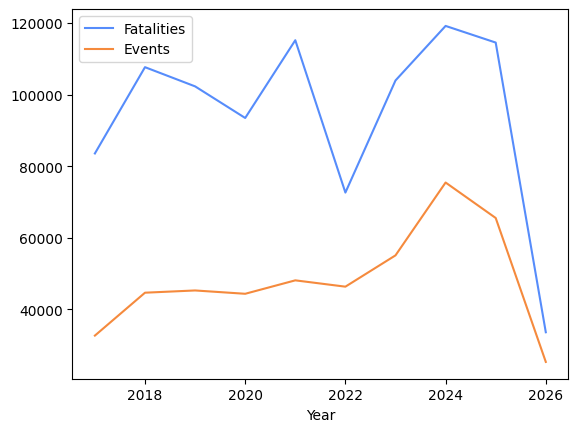

In [12]:
df_year_grouped.groupby('Year')[['Fatalities', 'Events']].sum().plot(kind='line')
plt.show()

In [13]:
import altair as alt
import pandas as pd

# 1. Creazione del menu a tendina (Dropdown, NON slider) per 'Country'
lista_nazioni = df_year_grouped['Country_name'].dropna().unique().tolist()
country_dropdown = alt.binding_select(options=lista_nazioni, name="Select Country: ")

# Inizializza la selezione sulla prima nazione disponibile
country_selection = alt.selection_point(
    fields=['Country_name'],
    bind=country_dropdown,
    value=lista_nazioni[0]
)

# 2. Base chart con applicazione del filtro
base = alt.Chart(df_year_grouped).transform_filter(
    country_selection
).encode(
    x=alt.X('Year:O', title='Year') # ':O' tratta l'anno come ordinale. Usa ':T' se è un datetime reale.
)

# 3. Asse Y Primario: Events e Fatalities
# Usa transform_fold per riorganizzare le colonne in righe e tracciarle con colori separati
chart_primary = base.transform_fold(
    ['Events', 'Fatalities'],
    as_=['Metric', 'Count']
).mark_line(point=True).encode(
    y=alt.Y('Count:Q', title='Events & Fatalities Count'),
    color=alt.Color('Metric:N', scale=alt.Scale(scheme='viridis'))
)

# 4. Asse Y Secondario: violence_ratio
# Tracciato con un pattern tratteggiato per distinguerlo dalle metriche assolute
chart_secondary = base.mark_line(strokeDash=[5, 5], color='red').encode(
    y=alt.Y('violence_ratio:Q', title='Violence Ratio (Red Dashed)')
)

# 5. Composizione finale
final_chart = alt.layer(
    chart_primary,
    chart_secondary
).resolve_scale(
    y='independent' # Cruciale: disaccoppia le scale dell'asse Y
).add_params(
    country_selection
).properties(
    width=700,
    height=400,
    title="Metrics and Violence Ratio by Country"
)

# Mostra il grafico
final_chart

alt.LayerChart(...)

In [14]:
df_month_grouped = df_violence.groupby(['Country_name', 'Year', "Month"])[['Fatalities', 'Events']].sum().reset_index()

In [15]:
import altair as alt
import pandas as pd

# 1. Pre-aggregazione in Pandas (Ottimizzazione obbligatoria)
# Raggruppa per Anno e Mese, calcolando la somma. Il reset_index appiattisce il dataframe.
df_agg = df_month_grouped.groupby(['Year', 'Month'])[['Events', 'Fatalities']].sum().reset_index()

# 2. Creazione del menu a tendina per 'Year'
lista_anni = sorted(df_agg['Year'].unique().tolist())
year_dropdown = alt.binding_select(options=lista_anni, name="Select Year: ")

year_selection = alt.selection_point(
    fields=['Year'],
    bind=year_dropdown,
    value=lista_anni[0]
)

# 3. Costruzione del grafico interattivo
chart = alt.Chart(df_agg).transform_filter(
    year_selection
).transform_fold(
    # Riorganizza le colonne in righe per tracciare due linee distinte
    ['Events', 'Fatalities'],
    as_=['Metric', 'Total']
).mark_line(point=True).encode(
    x=alt.X('Month:O', title='Month'), # ':O' (Ordinale) mantiene i mesi in sequenza corretta
    y=alt.Y('Total:Q', title='Sum of Events & Fatalities'),
    color=alt.Color('Metric:N', scale=alt.Scale(scheme='category10'))
).add_params(
    year_selection
).properties(
    width=700,
    height=400,
    title="Monthly Events and Fatalities by Year"
)

# Render
chart

alt.Chart(...)

In [16]:
# 1. Aggregate the total fatalities for every Admin1 region per Country and Year
df_admin1_totals = df_violence.groupby(['Country_name', 'Year', 'Admin1', 'Admin2'])['Fatalities'].sum().reset_index()

# 2. Find the index numbers of the rows with the highest fatalities for each Country/Year block
max_indices = df_admin1_totals.groupby(['Country_name', 'Year'])['Fatalities'].idxmax()

# 3. Use those index numbers to slice the exact rows out of the aggregated DataFrame
df_highest_fatalities = df_admin1_totals.loc[max_indices]

In [17]:
df_highest_fatalities

,Country_name,Year,Admin1,Admin2,Fatalities
260,Afghanistan,2017,Nangarhar,Achin,1880
509,Afghanistan,2018,Ghazni,Ghazni,1827
1173,Afghanistan,2019,Urozgan,Tirinkot,1443
1390,Afghanistan,2020,Kandahar,Maiwand,716
1731,Afghanistan,2021,Helmand,Lashkargah,1908
...,...,...,...,...,...
27121,Yemen,2022,Marib,Marib,577
27225,Yemen,2023,Ad Dali,Qaatabah,372
27558,Yemen,2024,Ad Dali,Qaatabah,414
27891,Yemen,2025,Ad Dali,Qaatabah,236


In [18]:

# 1. Aggregate both required metrics to the Admin1 level
df_admin1_rates = df_violence.groupby(['Country_name', 'Year', 'Admin1'])[['Fatalities', 'Events']].sum().reset_index()

# 2. Calculate the rate safely to prevent 'inf' values
df_admin1_rates['Fatality_Rate'] = np.where(
    df_admin1_rates['Events'] == 0,
    0,
    df_admin1_rates['Fatalities'] / df_admin1_rates['Events']
)

# 3. Extract the rows with the highest calculated rate
max_rate_indices = df_admin1_rates.groupby(['Country_name', 'Year'])['Fatality_Rate'].idxmax()
df_highest_rate = df_admin1_rates.loc[max_rate_indices]

In [19]:
df_highest_rate

,Country_name,Year,Admin1,Fatalities,Events,Fatality_Rate
31,Afghanistan,2017,Urozgan,2542,410,6.200000
46,Afghanistan,2018,Jowzjan,1057,175,6.040000
73,Afghanistan,2019,Daykundi,444,68,6.529412
107,Afghanistan,2020,Daykundi,453,68,6.661765
146,Afghanistan,2021,Helmand,4350,625,6.960000
...,...,...,...,...,...,...
2997,Yemen,2022,Al Mahwit,3,1,3.000000
3017,Yemen,2023,Al Jawf,115,101,1.138614
3035,Yemen,2024,Ad Dali,696,452,1.539823
3063,Yemen,2025,Al Mahwit,9,5,1.800000


In [20]:

# 1. Define the explicit macro-region mapping dictionary
region_map = {
    'Burundi': 'Sub-Saharan Africa', 'Cameroon': 'Sub-Saharan Africa',
    'Central African Republic': 'Sub-Saharan Africa', 'Democratic Republic of Congo': 'Sub-Saharan Africa',
    'Ethiopia': 'Sub-Saharan Africa', 'Somalia': 'Sub-Saharan Africa',
    'South Sudan': 'Sub-Saharan Africa', 'Sudan': 'Sub-Saharan Africa',
    'Burkina Faso': 'Sub-Saharan Africa', 'Chad': 'Sub-Saharan Africa',
    'Mali': 'Sub-Saharan Africa', 'Niger': 'Sub-Saharan Africa',
    'Nigeria': 'Sub-Saharan Africa', 'Mozambique': 'Sub-Saharan Africa',
    'Lebanon': 'Middle East & North Africa', 'Palestine': 'Middle East & North Africa',
    'Syria': 'Middle East & North Africa', 'Yemen': 'Middle East & North Africa',
    'Afghanistan': 'Asia & Pacific', 'Myanmar': 'Asia & Pacific',
    'Colombia': 'Latin America & Caribbean', 'Haiti': 'Latin America & Caribbean',
    'Venezuela': 'Latin America & Caribbean',
    'Ukraine': 'Eastern Europe'
}

# 2. Vectorized mapping operation to create the new column
df_violence['Macro_Region'] = df_violence['Country_name'].map(region_map)

# 3. Handle potential missing values safely
df_violence['Macro_Region'] = df_violence['Macro_Region'].fillna('Other')

# Now you can aggregate or plot by Macro_Region instead of individual countries
region_trends = df_violence.groupby(['Macro_Region', 'Year'])[['Fatalities', 'Events']].sum().reset_index()
region_trends

,Macro_Region,Year,Fatalities,Events
0,Asia & Pacific,2017,36350,12582
1,Asia & Pacific,2018,42987,13664
2,Asia & Pacific,2019,41419,13612
3,Asia & Pacific,2020,31029,9766
4,Asia & Pacific,2021,42421,9128
5,Asia & Pacific,2022,4152,2549
6,Asia & Pacific,2023,1152,1035
7,Asia & Pacific,2024,1363,1105
8,Asia & Pacific,2025,925,812
9,Asia & Pacific,2026,580,430


In [21]:
import altair as alt

# 1. Estrazione delle opzioni per il menu a tendina
lista_regioni = sorted(region_trends['Macro_Region'].dropna().unique().tolist())

# 2. Creazione dell'elemento UI (Dropdown)
region_dropdown = alt.binding_select(options=lista_regioni, name="Select Macro Region: ")
region_selection = alt.selection_point(
    fields=['Macro_Region'],
    bind=region_dropdown,
    value=lista_regioni[0]
)

# 3. Costruzione del grafico interattivo
chart = alt.Chart(region_trends).transform_filter(
    region_selection
).transform_fold(
    # Unfold per combinare Events e Fatalities nello stesso grafico con una legenda
    ['Events', 'Fatalities'],
    as_=['Metric', 'Count']
).mark_line(point=True).encode(
    x=alt.X('Year:O', title='Year'), # ':O' tratta l'anno come categoria ordinata. Usa ':T' se è una data ISO.
    y=alt.Y('Count:Q', title='Count'),
    color=alt.Color('Metric:N', scale=alt.Scale(scheme='set2')),
    tooltip=['Year:O', 'Metric:N', 'Count:Q'] # Aggiunta essenziale per l'ispezione interattiva
).add_params(
    region_selection
).properties(
    width=700,
    height=400,
    title="Yearly Events and Fatalities by Macro Region"
)

# Render del grafico
chart

alt.Chart(...)

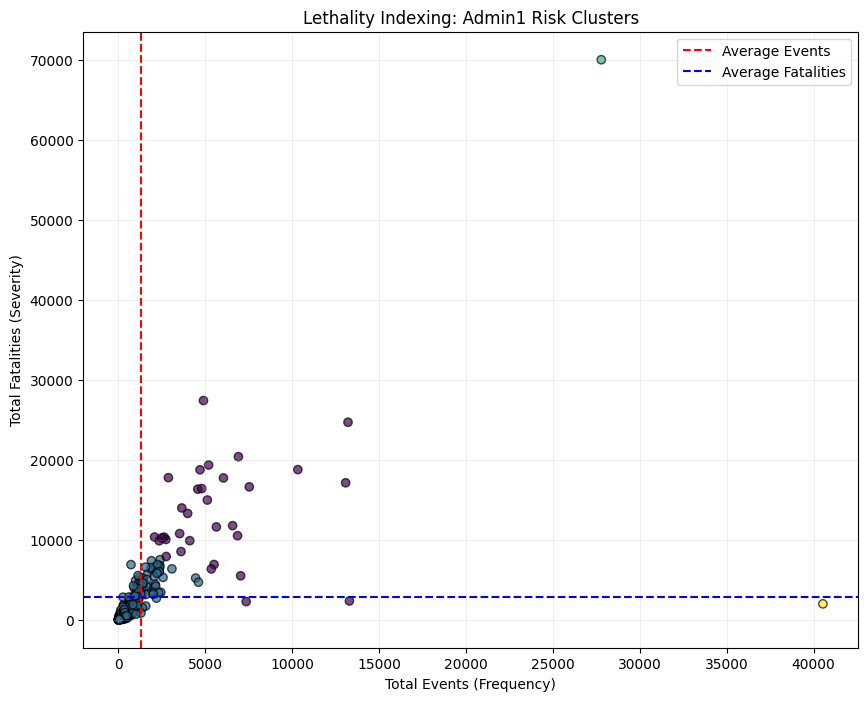

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Aggregate the historical totals to the Admin1 level
# We drop Year and Month to view the overarching systemic risk of the region
df_admin1 = df_violence.groupby(['Country_name', 'Admin1'])[['Events', 'Fatalities']].sum().reset_index()

# 2. Extract the features for machine learning
X = df_admin1[['Events', 'Fatalities']]

# 3. Standardize the data (CRITICAL STEP)
# This forces both columns to have equal weight in the distance calculation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Initialize and fit the K-Means algorithm
# We define 4 clusters to map to our Risk Quadrants concept
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_admin1['Risk_Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Visualize the quadrants
plt.figure(figsize=(10, 8))

# Plot each cluster with a different color
scatter = plt.scatter(
    df_admin1['Events'],
    df_admin1['Fatalities'],
    c=df_admin1['Risk_Cluster'],
    cmap='viridis',
    alpha=0.7,
    edgecolors='k'
)

# Add baseline averages to visually divide the chart into literal quadrants
plt.axvline(df_admin1['Events'].mean(), color='red', linestyle='--', label='Average Events')
plt.axhline(df_admin1['Fatalities'].mean(), color='blue', linestyle='--', label='Average Fatalities')

plt.title('Lethality Indexing: Admin1 Risk Clusters')
plt.xlabel('Total Events (Frequency)')
plt.ylabel('Total Fatalities (Severity)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print the regions assigned to the highest risk cluster (assuming Cluster 3 is highest; verify visually)
# print(df_admin1[df_admin1['Risk_Cluster'] == 3])

In [23]:
df_violence.columns

Index(['Country_name', 'Admin1', 'Admin2', 'ISO3', 'Admin2 Pcode',
       'Admin1 Pcode', 'Month', 'Year', 'Events', 'Fatalities', 'Country',
       'violence_ratio', 'Macro_Region'],
      dtype='object')

# DATASETS MERGE

In [24]:
df_ipc

,Date of analysis,Country,Total country population,Level 1,Area,Validity period,From,To,Phase,Number,Percentage,adm1_pcode,adm2_pcode
0,Oct-25,AFG,48595631,North Eastern Region,Badakhshan,current,01/09/2025,31/10/2025,3+,671809,0.40,AF17,AF17
1,Oct-25,AFG,48595631,North Eastern Region,Badakhshan,first projection,01/11/2025,31/03/2026,3+,755786,0.45,AF17,AF17
2,Oct-25,AFG,48595631,North Eastern Region,Badakhshan,second projection,01/04/2026,30/09/2026,3+,671810,0.40,AF17,AF17
3,Oct-25,AFG,48595631,North Eastern Region,Baghlan,current,01/09/2025,31/10/2025,3+,601580,0.35,AF09,AF09
4,Oct-25,AFG,48595631,North Eastern Region,Baghlan,first projection,01/11/2025,31/03/2026,3+,773460,0.45,AF09,AF09
...,...,...,...,...,...,...,...,...,...,...,...,...,...
64209,Feb-19,ZWE,14645000,Masvingo,Mwenezi,current,01/02/2019,31/05/2019,3+,70907,0.40,ZW18,ZW1806
64210,Feb-19,ZWE,14645000,Masvingo,Chivi,current,01/02/2019,31/05/2019,3+,44066,0.25,ZW18,ZW1803
64211,Feb-19,ZWE,14645000,Masvingo,Zaka,current,01/02/2019,31/05/2019,3+,48114,0.25,ZW18,ZW1807
64212,Feb-19,ZWE,14645000,Masvingo,Chiredzi,current,01/02/2019,31/05/2019,3+,102453,0.35,ZW18,ZW1822


In [25]:
print("df_violence")
print(df_violence["Admin1 Pcode"].unique().tolist())
print("")
print("df_ipc")
print(df_ipc.adm1_pcode.unique().tolist())

df_violence
['HT01', 'HT09', 'HT06', 'HT03', 'HT07', 'HT04', 'HT05', 'HT10', 'HT08', 'HT02', nan, 'ML07', 'ML01', 'ML03', 'ML02', 'ML09', 'ML06', 'ML04', 'ML05', 'ML10', 'ML08', 'MZ09', 'MZ01', 'MZ05', 'MZ10', 'MZ07', 'MZ02', 'MZ03', 'MZ08', 'MZ11', 'MZ04', 'MZ06', 'NER007', 'NER001', 'NER004', 'NER006', 'NER002', 'NER003', 'NER005', 'NER008', 'NG00', 'NG01', 'NG03', 'NG02', 'PS02', 'PS01', 'SO13', 'SO14', 'SO12', 'SO16', 'SO11', 'SO15', 'SO20', 'SO25', 'SO21', 'SO24', 'SO17', 'SO27', 'SO19', 'SO18', 'SO23', 'SO26', 'SO28', 'SO22', 'SS04', 'SS06', 'SS02', 'SS10', 'SS01', 'SS07', 'SS03', 'SS08', 'SS09', 'SS05', 'SD04', 'SD15', 'SD12', 'SD14', 'SD18', 'SD10', 'SD17', 'SD07', 'SD09', 'SD02', 'SD08', 'SD05', 'SD01', 'SD11', 'SD13', 'SD03', 'SD06', 'SD16', 'SD19', 'YE29', 'YE24', 'YE23', 'YE11', 'YE18', 'YE19', 'YE28', 'YE12', 'YE13', 'YE14', 'YE31', 'YE15', 'YE21', 'YE20', 'YE16', 'YE27', 'YE17', 'YE26', 'YE32', 'YE25', 'YE22', 'YE30', 'AF09', 'AF03', 'AF07', 'AF17', 'AF20', 'AF06', 'AF25'

In [26]:
print("df_violence")
print(df_violence["Admin2 Pcode"].unique().tolist())
print("")
print("df_ipc")
print(df_ipc.adm2_pcode.unique().tolist())

df_violence
['HT0142', 'HT0931', 'HT0611', 'HT0321', 'HT0111', 'HT0731', 'HT0441', 'HT0531', 'HT0151', 'HT0542', 'HT0743', 'HT0331', 'HT1031', 'HT0821', 'HT0421', 'HT0621', 'HT0711', 'HT1021', 'HT0431', 'HT0911', 'HT0834', 'HT0512', 'HT0751', 'HT0121', 'HT0371', 'HT0341', 'HT0721', 'HT0212', 'HT0631', 'HT0921', 'HT0551', 'HT1011', 'HT0521', 'HT0361', 'HT0351', 'HT0641', 'HT0231', 'HT0131', 'HT0411', 'HT0311', 'HT0221', 'HT0811', nan, 'ML0701', 'ML0105', 'ML0305', 'ML0205', 'ML0207', 'ML0702', 'ML0302', 'ML0901', 'ML0304', 'ML0601', 'ML0201', 'ML0406', 'ML0505', 'ML0402', 'ML1003', 'ML0501', 'ML0404', 'ML0106', 'ML0604', 'ML0507', 'ML0405', 'ML0301', 'ML0202', 'ML0506', 'ML0403', 'ML1002', 'ML0602', 'ML1001', 'ML0508', 'ML0206', 'ML1004', 'ML0204', 'ML0102', 'ML0307', 'ML0605', 'ML0503', 'ML0603', 'ML0407', 'ML0504', 'ML0502', 'ML0306', 'ML0401', 'ML0804', 'ML0103', 'ML0104', 'ML0107', 'ML0803', 'ML0703', 'ML0203', 'ML0801', 'ML0101', 'ML0303', 'ML0802', 'MZ0904', 'MZ0113', 'MZ0114', 'M

In [27]:
ad1_uguale = []
ad2_uguale = []
c=0
for ad1 in df_ipc.adm1_pcode.unique().tolist():
    for ad2 in df_ipc.adm2_pcode.unique().tolist():
        if ad1 == ad2:
            ad1_uguale.append(ad1)
            ad2_uguale.append(ad2)
            c+=1

print(len(ad1_uguale), len(df_ipc.adm1_pcode.unique().tolist()))
print(len(ad2_uguale), len(df_ipc.adm2_pcode.unique().tolist()))


326 702
326 3548


In [28]:
import pandas as pd

# 1. Sostituzione sistemica dei prefissi (ISO-2 vs ISO-3 o formati anomali)
# Creazione di un dizionario basato sulle discrepanze oggettive rilevate
prefix_mapping = {
    r'^TD': 'TCD',   # Converte TD14 in TCD14
    r'^NER': 'NE'    # Converte NER007 in NE007
}

# Assumendo che la colonna in df_violence si chiami "Pcode"
df_violence["Pcode_aligned"] = (
    df_violence["Admin1 Pcode"]
    .astype(str) # Evita errori causati dai NaN
    .replace(prefix_mapping, regex=True)
)

# 2. Ripristino dei NaN (precedentemente convertiti nella stringa 'nan')
import numpy as np
df_violence["Pcode_aligned"] = df_violence["Pcode_aligned"].replace('nan', np.nan)

# 3. Mappatura esplicita per i codici troncati/ambigui (es. Nigeria e Camerun)
# Questa mappa DEVE essere validata controllando i nomi delle province, non dedotta a caso.
# Qui un esempio di come applicarla in blocco:
mappatura_troncati = {
    "NG00": "NG001", # SOSTITUIRE CON IL VALORE REALE CORRETTO
    "NG01": "NG015", # SOSTITUIRE CON IL VALORE REALE CORRETTO
    "CM00": "CM001", # SOSTITUIRE CON IL VALORE REALE CORRETTO
    "CM01": "CM010"  # SOSTITUIRE CON IL VALORE REALE CORRETTO
}

df_violence["Pcode_aligned"] = df_violence["Pcode_aligned"].replace(mappatura_troncati)

# 4. Isolamento degli orfani rimanenti
# Sostituisci la riga 34 difettosa con questa:
codici_ipc_validi = set(df_ipc["adm1_pcode"].dropna())
codici_violence_validi = set(df_violence["Pcode_aligned"].dropna())

codici_orfani = codici_violence_validi - codici_ipc_validi

# Mappatura per risolvere i problemi di padding o prefisso evidenti
mappatura_manuale_risolvibile = {
    "NG02": "NG002",
    "NG03": "NG003"
    # L'eventuale conversione di BDI in BD dipende dalla tua anagrafica:
    # BDI001 potrebbe corrispondere a BD10, ma devi verificarlo.
}

df_violence["Pcode_aligned"] = df_violence["Pcode_aligned"].replace(mappatura_manuale_risolvibile)
# 1. Definisci la lista dei codici irrisolti
codici_assenti = ['BDI017', 'BDI006', 'BDI012', 'BDI014', 'TCD18', 'BF52', 'ET13', 'PS01', 'BDI015', 'BDI008', 'BDI009', 'ET14', 'BDI016', 'BDI007', 'BDI002', 'BDI003', 'ET15', 'BDI010', 'BDI018', 'BDI011', 'BDI001', 'BF56', 'BDI004', 'BDI005', 'ET06', 'ET12', 'BDI013', 'BF46']

# 2. Estrai i nomi delle regioni da df_violence per questi codici
# Sostituisci "Admin1_Name" con il nome reale della tua colonna contenente le stringhe geografiche
df_da_indagare = df_violence[df_violence["Pcode_aligned"].isin(codici_assenti)][["Pcode_aligned", "Admin1 Pcode"]].drop_duplicates()

print(df_da_indagare)

       Pcode_aligned Admin1 Pcode
394448          PS01         PS01
55779           BF52         BF52
55784           BF56         BF56
55788           BF46         BF46
89419         BDI013       BDI013
89420         BDI008       BDI008
89421         BDI001       BDI001
89422         BDI010       BDI010
89423         BDI003       BDI003
89424         BDI004       BDI004
89425         BDI006       BDI006
89426         BDI011       BDI011
89427         BDI007       BDI007
89429         BDI005       BDI005
89431         BDI002       BDI002
89435         BDI016       BDI016
89443         BDI018       BDI018
89451         BDI014       BDI014
89452         BDI015       BDI015
89458         BDI009       BDI009
89465         BDI012       BDI012
89493         BDI017       BDI017
165614         TCD18         TD18
375237          ET13         ET13
375239          ET12         ET12
375242          ET06         ET06
375264          ET15         ET15
375317          ET14         ET14


In [29]:
import pandas as pd
import numpy as np

# Creazione del set di ricerca ottimizzato (O(1) lookup) ignorando i NaN
# Sostituisci la stringa con l'effettiva etichetta della colonna che contiene i Pcode
codici_ipc_validi = set(df_ipc["adm2_pcode"].dropna())

def allinea_pcode_gerarchico(pcode, valid_set):
    """
    Tenta di allineare il Pcode normalizzando i prefissi e troncando
    la stringa gerarchicamente per trovare l'Admin level superiore.
    """
    if pd.isna(pcode):
        return np.nan

    pcode_str = str(pcode).strip().upper()

    # 1. Normalizzazione sistemica dei prefissi anomali noti
    if pcode_str.startswith('NER'):
        pcode_str = pcode_str.replace('NER', 'NE', 1)
    elif pcode_str.startswith('TD'):
        pcode_str = pcode_str.replace('TD', 'TCD', 1)

    # 2. Controllo match esatto (stesso livello di granularità)
    if pcode_str in valid_set:
        return pcode_str

    # 3. Troncamento gerarchico (da destra verso sinistra)
    # Es: se AF0912 non esiste, cerca AF091, poi AF09. Si ferma a 2 caratteri (codice nazione).
    for i in range(len(pcode_str) - 1, 2, -1):
        troncato = pcode_str[:i]
        if troncato in valid_set:
            return troncato

    # Se il ciclo finisce senza match, il dato spaziale manca nel target
    return np.nan

# Applicazione vettoriale tramite apply (il set viene passato come argomento per efficienza)
# Assumendo che la colonna in df_violence si chiami "Pcode"
df_violence["Pcode_aligned"] = df_violence["Admin2 Pcode"].apply(
    lambda x: allinea_pcode_gerarchico(x, codici_ipc_validi)
)

# Verifica implacabile del tasso di fallimento
nulli_post_allineamento = df_violence["Pcode_aligned"].isna().sum()
print(f"Record non allineabili (dati spaziali mancanti in df_ipc): {nulli_post_allineamento}")

Record non allineabili (dati spaziali mancanti in df_ipc): 49245


In [30]:
df_ipc

,Date of analysis,Country,Total country population,Level 1,Area,Validity period,From,To,Phase,Number,Percentage,adm1_pcode,adm2_pcode
0,Oct-25,AFG,48595631,North Eastern Region,Badakhshan,current,01/09/2025,31/10/2025,3+,671809,0.40,AF17,AF17
1,Oct-25,AFG,48595631,North Eastern Region,Badakhshan,first projection,01/11/2025,31/03/2026,3+,755786,0.45,AF17,AF17
2,Oct-25,AFG,48595631,North Eastern Region,Badakhshan,second projection,01/04/2026,30/09/2026,3+,671810,0.40,AF17,AF17
3,Oct-25,AFG,48595631,North Eastern Region,Baghlan,current,01/09/2025,31/10/2025,3+,601580,0.35,AF09,AF09
4,Oct-25,AFG,48595631,North Eastern Region,Baghlan,first projection,01/11/2025,31/03/2026,3+,773460,0.45,AF09,AF09
...,...,...,...,...,...,...,...,...,...,...,...,...,...
64209,Feb-19,ZWE,14645000,Masvingo,Mwenezi,current,01/02/2019,31/05/2019,3+,70907,0.40,ZW18,ZW1806
64210,Feb-19,ZWE,14645000,Masvingo,Chivi,current,01/02/2019,31/05/2019,3+,44066,0.25,ZW18,ZW1803
64211,Feb-19,ZWE,14645000,Masvingo,Zaka,current,01/02/2019,31/05/2019,3+,48114,0.25,ZW18,ZW1807
64212,Feb-19,ZWE,14645000,Masvingo,Chiredzi,current,01/02/2019,31/05/2019,3+,102453,0.35,ZW18,ZW1822


In [31]:
import pandas as pd

# 1. Dizionario di conversione da nome esteso a tre lettere (Inglese)
month_to_short = {
    'January': 'Jan', 'February': 'Feb', 'March': 'Mar', 'April': 'Apr',
    'May': 'May', 'June': 'Jun', 'July': 'Jul', 'August': 'Aug',
    'September': 'Sep', 'October': 'Oct', 'November': 'Nov', 'December': 'Dec'
}

# 2. Controllo preventivo per evitare valori nulli dovuti a typo nel dataset
if not df_violence['Month'].isin(month_to_short.keys()).all():
    invalidi = df_violence[~df_violence['Month'].isin(month_to_short.keys())]['Month'].unique()
    raise ValueError(f"Stringhe mese non valide rilevate: {invalidi}")

# 3. Creazione della colonna richiesta 'Date of analysis'
df_violence['Date of analysis'] = (
    df_violence['Month'].map(month_to_short) +
    '-' +
    df_violence['Year'].astype(str).str[-2:]
)

In [32]:
df_violence.rename(columns={'Admin1 Pcode': 'adm1_pcode', 'Admin2 Pcode': 'adm2_pcode'}, inplace=True)

In [33]:
df_violence = df_violence[['Country','adm2_pcode', 'adm1_pcode','Events', 'Fatalities', 'Date of analysis', 'violence_ratio']]

In [34]:
# 1. Definizione delle chiavi di join
join_keys = ['Country', 'Date of analysis', 'adm1_pcode', 'adm2_pcode']

# 2. Subsetting preventivo: estrai SOLO le chiavi e le metriche di interesse
# Assicurati che 'violence_ratio' esista o rimuovilo dalla lista se lo calcoli dopo
df_violence_subset = df_violence[join_keys + ['Events', 'Fatalities', 'violence_ratio']]

# 3. Rimozione dei duplicati sul dataset di destra (Se non rimuovi e ci sono duplicati, il validate fallirà)
# Modifica questa logica se hai bisogno di aggregare (es. sommare) anziché droppare i duplicati
df_violence_subset = df_violence_subset.drop_duplicates(subset=join_keys)

# 4. Left Join strutturato con validazione della cardinalità
df_unito = pd.merge(
    df_ipc,               # Dataset principale (Sinistra)
    df_violence_subset,   # Dataset di lookup (Destra)
    on=join_keys,
    how='left',           # Mantieni tutti i record di df_ipc
    validate='m:1'        # GARANZIA: Blocca l'esecuzione se ci sono duplicati nelle chiavi di destra
)

In [ ]:
%%sql


In [35]:
df_unito

,Date of analysis,Country,Total country population,Level 1,Area,Validity period,From,To,Phase,Number,Percentage,adm1_pcode,adm2_pcode,Events,Fatalities,violence_ratio
0,Oct-25,AFG,48595631,North Eastern Region,Badakhshan,current,01/09/2025,31/10/2025,3+,671809,0.40,AF17,AF17,NaN,NaN,NaN
1,Oct-25,AFG,48595631,North Eastern Region,Badakhshan,first projection,01/11/2025,31/03/2026,3+,755786,0.45,AF17,AF17,NaN,NaN,NaN
2,Oct-25,AFG,48595631,North Eastern Region,Badakhshan,second projection,01/04/2026,30/09/2026,3+,671810,0.40,AF17,AF17,NaN,NaN,NaN
3,Oct-25,AFG,48595631,North Eastern Region,Baghlan,current,01/09/2025,31/10/2025,3+,601580,0.35,AF09,AF09,NaN,NaN,NaN
4,Oct-25,AFG,48595631,North Eastern Region,Baghlan,first projection,01/11/2025,31/03/2026,3+,773460,0.45,AF09,AF09,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64209,Feb-19,ZWE,14645000,Masvingo,Mwenezi,current,01/02/2019,31/05/2019,3+,70907,0.40,ZW18,ZW1806,NaN,NaN,NaN
64210,Feb-19,ZWE,14645000,Masvingo,Chivi,current,01/02/2019,31/05/2019,3+,44066,0.25,ZW18,ZW1803,NaN,NaN,NaN
64211,Feb-19,ZWE,14645000,Masvingo,Zaka,current,01/02/2019,31/05/2019,3+,48114,0.25,ZW18,ZW1807,NaN,NaN,NaN
64212,Feb-19,ZWE,14645000,Masvingo,Chiredzi,current,01/02/2019,31/05/2019,3+,102453,0.35,ZW18,ZW1822,NaN,NaN,NaN


In [36]:
df_ipc.shape

(64214, 13)

In [37]:
df_unito["null%"] = df_unito.groupby("Country")["Events"].transform(lambda x: x.isna().mean() * 100)

In [38]:
df_null = df_unito[["Country", "null%"]].drop_duplicates().reset_index(drop=True)
df_null

,Country,null%
0,AFG,70.401211
1,AGO,100.000000
2,BDI,100.000000
3,BEN,100.000000
4,BFA,38.845144
5,BGD,93.577982
6,CAF,26.074499
7,CIV,100.000000
8,CMR,100.000000
9,COD,4.883721


In [39]:
df_null.set_index("Country")["null%"].to_dict()

{'AFG': 70.40121120363361,
 'AGO': 100.0,
 'BDI': 100.0,
 'BEN': 100.0,
 'BFA': 38.84514435695538,
 'BGD': 93.57798165137615,
 'CAF': 26.07449856733524,
 'CIV': 100.0,
 'CMR': 100.0,
 'COD': 4.883720930232558,
 'CPV': 100.0,
 'DJI': 86.66666666666667,
 'DOM': 96.31147540983606,
 'ECU': 100.0,
 'ETH': 45.467032967032964,
 'GHA': 100.0,
 'GIN': 100.0,
 'GMB': 100.0,
 'GNB': 100.0,
 'GTM': 99.36170212765958,
 'HND': 98.52507374631269,
 'HTI': 92.66943291839557,
 'KEN': 91.81692094313453,
 'LBN': 74.65857359635811,
 'LBR': 100.0,
 'LSO': 100.0,
 'MDG': 97.48427672955975,
 'MLI': 37.396121883656505,
 'MOZ': 5.211081794195251,
 'MRT': 99.39516129032258,
 'MWI': 100.0,
 'NAM': 95.0,
 'NER': 100.0,
 'NGA': 100.0,
 'PAK': 98.34482758620689,
 'PSE': 34.61538461538461,
 'SDN': 9.236590251502337,
 'SEN': 100.0,
 'SLE': 100.0,
 'SLV': 100.0,
 'SOM': 8.334175169209011,
 'SSD': 1.2979839823253245,
 'SWZ': 56.49717514124294,
 'TCD': 100.0,
 'TGO': 100.0,
 'TLS': 92.85714285714286,
 'TZA': 94.814814814

In [40]:
alt.Chart(df_null).mark_bar().encode(
    x=alt.X("Country:N", sort="-y"),
    y="null%",
    tooltip=["Country","null%"]
)

alt.Chart(...)